# Causal structure preservation pipeline

This notebook walks through the causal-structure preservation pipeline in a representative way.
It is intended for inspection and teaching; the frozen paper results live under `results/`.

After **Stage I (data)** and **Stage II (encoding)** the pipeline splits into two separate paths:

* **Raw-neuron path** — encoded spikes are immediately reduced to one scalar per variable per sample, then fed to causal discovery.
* **Assembly path** — the same encoded spikes first go through assembly formation (k-WTA competition + Hebbian plasticity), then through an assembly-level readout, then to causal discovery.

Both paths use identical discovery settings so that any difference in the recovered DAG is attributable solely to the representational transformation.

The notebook runs both paths for **two encoding schemes**: Bernoulli and deterministic-k.

In [68]:
from pathlib import Path
import contextlib, io, sys

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

cwd = Path.cwd().resolve()
if (cwd / "src").exists():
    REPO_ROOT = cwd
elif (cwd.parent / "src").exists():
    REPO_ROOT = cwd.parent
else:
    raise RuntimeError("Run from repo root or notebooks/.")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from experiments.student_success.validate_student_success import generate_student_data
from src.brain import Brain
from src.causal_dag import compare_dags
from src.discovery.ges import run_ges_algorithm
from src.discovery.pc import run_pc_algorithm
from src.encoding.bernoulli import encode_bernoulli_dataframe
from src.encoding.deterministic_k import build_deterministic_k_map, encode_deterministic_k_dataframe
from src.validation.assembly_feature_extraction import extract_assembly_features
from src.validation.assembly_formation import form_assemblies

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
print(f"repo root: {REPO_ROOT}")

repo root: C:\Users\A1110561\OneDrive - BI Norwegian Business School (BIEDU)\Documents\My\PHD\Repos\assemblies-encoding


## Configuration

Small dimensions so the notebook runs interactively.
The paper tables use the larger frozen runs under `results/`.

In [69]:
SEED            = 42
N_SAMPLES       = 1000
NEURONS_PER_VAR = 400
ASSEMBLY_K      = 40
N_TRAIN         = 200
N_PRESENTATIONS = 3
BETA            = 0.05
METHOD          = "pc"   # change to "ges" to test the score-based path

VAR_NAMES = ["PriorGPA", "Attendance", "StudyHours", "FinalExamScore", "FinalGrade"]

POSITIVE_VALUES_MAP = {
    "PriorGPA":       {"High", "Honors"},
    "Attendance":     {"Good"},
    "StudyHours":     {"High"},
    "FinalExamScore": {"Excellent"},
    "FinalGrade":     {"Excellent"},
}

DAG_POS = {
    "PriorGPA":       (-1.30,  1.4),
    "Attendance":     ( 0.0,   1.4),
    "StudyHours":     ( 1.30,  1.4),
    "FinalExamScore": ( 0.65,  0.0),
    "FinalGrade":     (-0.30, -1.4),
}

## Helpers

In [70]:
def encode(df, *, deterministic_k: bool):
    if deterministic_k:
        k_map = build_deterministic_k_map(df, VAR_NAMES, base_k=ASSEMBLY_K, k_step=8)
        neural, stim_idx = encode_deterministic_k_dataframe(
            df, VAR_NAMES, neurons_per_var=NEURONS_PER_VAR, stimulus_k_map=k_map, seed=SEED)
        return neural, stim_idx
    neural = encode_bernoulli_dataframe(
        df, VAR_NAMES, neurons_per_var=NEURONS_PER_VAR,
        positive_values_map=POSITIVE_VALUES_MAP,
        positive_prob=0.30, negative_prob=0.10, seed=SEED)
    return neural, None


def neuron_readout(neural, stim_idx=None, *, deterministic_k=False):
    features = {}
    for idx, var in enumerate(VAR_NAMES):
        block = neural[:, idx*NEURONS_PER_VAR:(idx+1)*NEURONS_PER_VAR]
        if deterministic_k and stim_idx and var in stim_idx:
            pos_vals = [v for v in POSITIVE_VALUES_MAP.get(var, set()) if v in stim_idx[var]]
            if pos_vals:
                local = np.concatenate([stim_idx[var][v] for v in pos_vals])
                features[var] = block[:, local].mean(axis=1)
                continue
        features[var] = block.mean(axis=1)
    return pd.DataFrame(features)


def assembly_formation(neural):
    brain = Brain(p=BETA, save_size=True, save_winners=True, seed=SEED)
    for var in VAR_NAMES:
        brain.add_area(var, n=NEURONS_PER_VAR, k=ASSEMBLY_K, beta=BETA)
    return form_assemblies(
        brain, neural, VAR_NAMES, NEURONS_PER_VAR,
        n_train=N_TRAIN, n_presentations=N_PRESENTATIONS,
        target_area_by_var_name={v: v for v in VAR_NAMES}, shuffle_seed=SEED)


def assembly_readout(neural, brain):
    feats = extract_assembly_features(
        neural, brain, VAR_NAMES, NEURONS_PER_VAR,
        source_var_by_target_area_name={v: v for v in VAR_NAMES})
    return pd.DataFrame({k: v for k, v in feats.items() if "_x_" not in k})


def discover(feature_df):
    if METHOD == "pc":
        edges, _ = run_pc_algorithm(feature_df, VAR_NAMES, alpha=0.05, strict=False)
    else:
        edges, _ = run_ges_algorithm(feature_df, VAR_NAMES, strict=False)
    return edges


import math as _math
from matplotlib.patches import Circle as _Circle, FancyArrowPatch as _FAP

_NODE_R  = 0.34
_LABEL_FS = 8.0
_TITLE_FS = 10

_WRAP = {
    "FinalExamScore": "FinalExam\nScore",
    "FinalGrade":     "Final\nGrade",
    "StudyHours":     "Study\nHours",
    "PriorGPA":       "Prior\nGPA",
}


def _clip(pos_s, pos_t, r=_NODE_R):
    sx, sy = pos_s; tx, ty = pos_t
    dx, dy = tx - sx, ty - sy
    d = _math.hypot(dx, dy)
    if d == 0:
        return pos_s, pos_t
    ux, uy = dx / d, dy / d
    return (sx + ux * r, sy + uy * r), (tx - ux * (r + 0.02), ty - uy * (r + 0.02))


def draw_dag(ax, edges, title, node_color, gt_edges=None):
    ax.set_xlim(-1.85, 1.85); ax.set_ylim(-2.05, 2.05)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_title(title, fontsize=_TITLE_FS, pad=8, fontweight="bold")

    gt = set(map(tuple, gt_edges)) if gt_edges else None

    for s, t in edges:
        if s not in DAG_POS or t not in DAG_POS:
            continue
        if gt is None:
            col = "#37474F"
        elif (s, t) in gt:
            col = "#2E7D32"
        else:
            col = "#C62828"
        start, end = _clip(DAG_POS[s], DAG_POS[t])
        patch = _FAP(
            posA=start, posB=end,
            arrowstyle="-|>",
            mutation_scale=20,
            linewidth=2.2,
            color=col,
            zorder=1,
        )
        ax.add_patch(patch)

    for var in VAR_NAMES:
        x, y = DAG_POS[var]
        ax.add_patch(_Circle((x, y), _NODE_R,
                             facecolor=node_color, edgecolor="#263238",
                             linewidth=2.0, zorder=2))
        label = _WRAP.get(var, var)
        ax.text(x, y, label, ha="center", va="center",
                fontsize=_LABEL_FS, fontweight="semibold", zorder=3,
                multialignment="center", color="#1a1a1a")

    if gt_edges:
        ax.plot([], [], color="#2E7D32", lw=2.5, label="correct")
        ax.plot([], [], color="#C62828", lw=2.5, label="spurious")
        ax.legend(loc="lower center", fontsize=7.5, framealpha=0.75,
                  ncol=2, handlelength=1.4, borderpad=0.5)


## Stage I — SCM data generation

dataset: (1000, 5)
ground-truth edges:
  PriorGPA -> FinalGrade
  Attendance -> FinalExamScore
  StudyHours -> FinalExamScore
  FinalExamScore -> FinalGrade


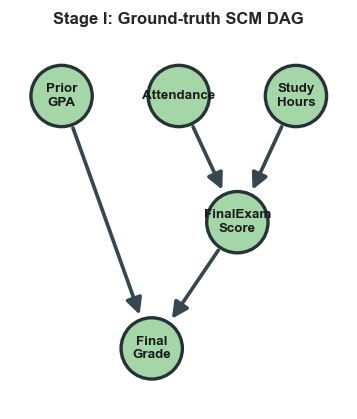

In [71]:
with contextlib.redirect_stdout(io.StringIO()):
    df, GT_EDGES = generate_student_data(n_students=N_SAMPLES, seed=SEED, variant="rich")

print(f"dataset: {df.shape}")
print("ground-truth edges:")
for s, t in GT_EDGES:
    print(f"  {s} -> {t}")

fig, ax = plt.subplots(figsize=(5, 4))
draw_dag(ax, GT_EDGES, "Stage I: Ground-truth SCM DAG", "#A5D6A7")
plt.show()

## Stage II — symbolic-to-spike encoding

The same observations are encoded twice: once with **Bernoulli** (stochastic, overlap-prone)
and once with **deterministic-k** (fixed value-specific active indices, low overlap).
Both produce an `N_SAMPLES × (len(VAR_NAMES) × NEURONS_PER_VAR)` binary spike matrix.

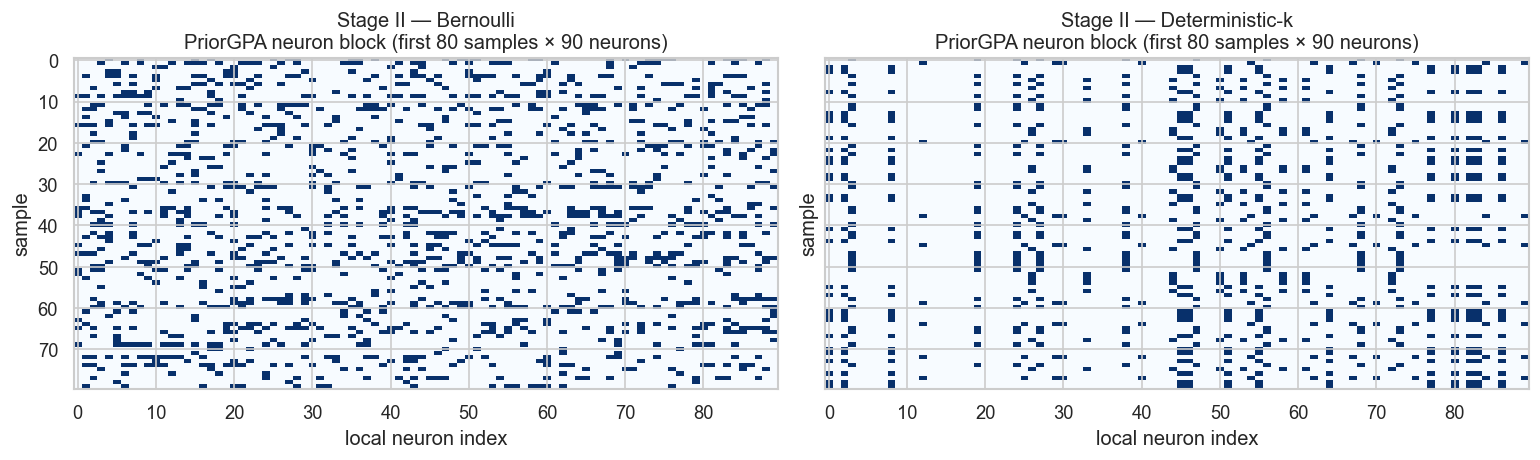

In [72]:
bern_neural,  bern_stim_idx  = encode(df, deterministic_k=False)
detk_neural,  detk_stim_idx  = encode(df, deterministic_k=True)

# Show spike block for PriorGPA under both encodings
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, neural) in zip(axes, [("Bernoulli", bern_neural), ("Deterministic-k", detk_neural)]):
    block = neural[:80, :90]
    ax.imshow(block, aspect="auto", interpolation="nearest", cmap="Blues")
    ax.set_title(f"Stage II — {label}\nPriorGPA neuron block (first 80 samples × 90 neurons)")
    ax.set_xlabel("local neuron index"); ax.set_ylabel("sample")
plt.tight_layout(); plt.show()

---
## After encoding: two separate paths

| | Raw-neuron path | Assembly path |
|---|---|---|
| Input | encoded spike matrix | encoded spike matrix |
| Step 1 | **direct readout (pool-mean over local neuron block)** (pool mean or positive-subset mean) | **assembly formation** (k-WTA + Hebbian plasticity) |
| Step 2 | — | **assembly readout** (population averaging over connectomes) |
| Output | neuron feature DataFrame | assembly feature DataFrame |
| Shared final step | **causal discovery** (PC or GES) | **causal discovery** (PC or GES) |

Both paths end at the same discovery and comparison step with identical algorithm settings.

### Raw-neuron path — direct readout (pool-mean over local neuron block)

Each variable is reduced to one scalar per sample directly from its local neuron block (no assembly step).

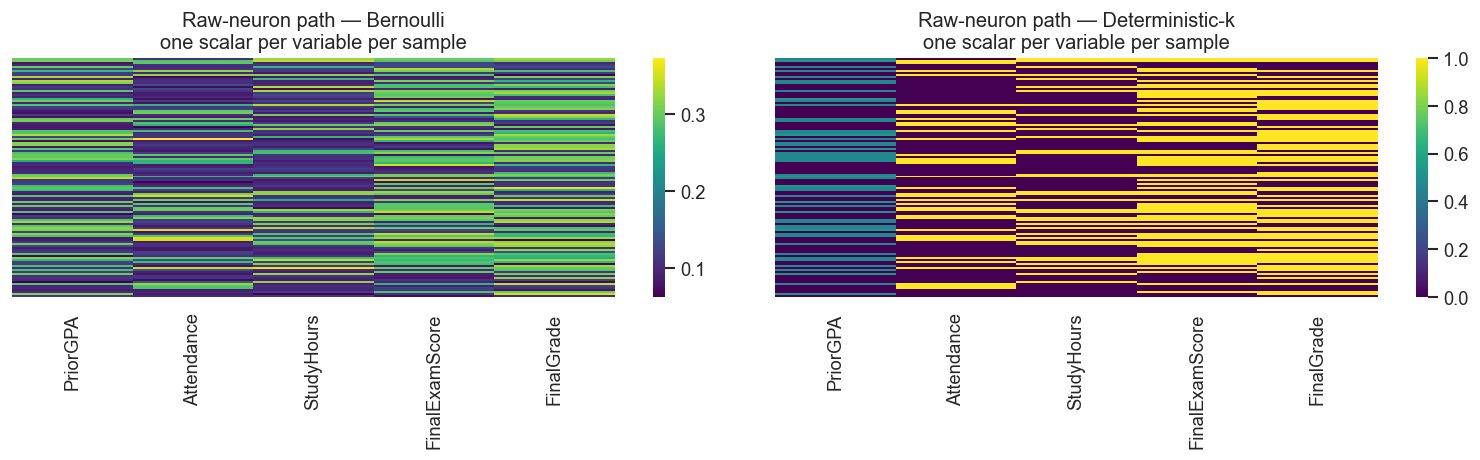

In [73]:
bern_neuron_df = neuron_readout(bern_neural, bern_stim_idx, deterministic_k=False)
detk_neuron_df = neuron_readout(detk_neural, detk_stim_idx, deterministic_k=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, df_feat) in zip(axes, [("Bernoulli", bern_neuron_df), ("Deterministic-k", detk_neuron_df)]):
    sns.heatmap(df_feat.head(120), ax=ax, cmap="viridis", cbar=True,
                xticklabels=True, yticklabels=False)
    ax.set_title(f"Raw-neuron path — {label}\none scalar per variable per sample")
plt.tight_layout(); plt.show()

### Assembly path — step 1: assembly formation

Encoded activity is projected into Brain areas for `N_PRESENTATIONS` rounds.
k-WTA competition keeps only the top-k active neurons per projection; Hebbian
plasticity strengthens co-activated connections. The bar chart shows final
assembly support size `w` (how many neurons have ever fired in each area).

Forming assemblies for Bernoulli encoding ...
Forming assemblies for Deterministic-k encoding ...


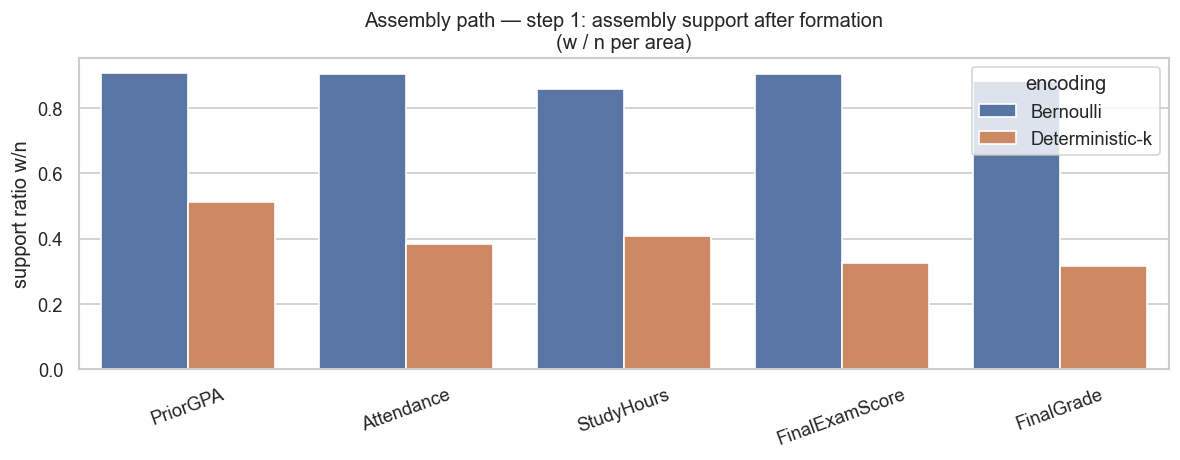

encoding,Bernoulli,Deterministic-k
variable,,
Attendance,362,153
FinalExamScore,362,130
FinalGrade,353,126
PriorGPA,363,205
StudyHours,343,163


In [74]:
print("Forming assemblies for Bernoulli encoding ...")
bern_brain = assembly_formation(bern_neural)
print("Forming assemblies for Deterministic-k encoding ...")
detk_brain = assembly_formation(detk_neural)

rows = []
for label, brain in [("Bernoulli", bern_brain), ("Deterministic-k", detk_brain)]:
    for var in VAR_NAMES:
        area = brain.area_by_name[var]
        rows.append({"encoding": label, "variable": var,
                     "support_w": area.w, "support_ratio": area.w / area.n})
support_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=support_df, x="variable", y="support_ratio", hue="encoding", ax=ax)
ax.set_title("Assembly path — step 1: assembly support after formation\n(w / n per area)")
ax.set_ylabel("support ratio w/n"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.show()
display(support_df.pivot(index="variable", columns="encoding", values="support_w"))

### Assembly path — step 2: assembly readout

The formed Brain is reused to extract one assembly-level scalar per variable per sample
via population averaging over learned stimulus-area connectomes.

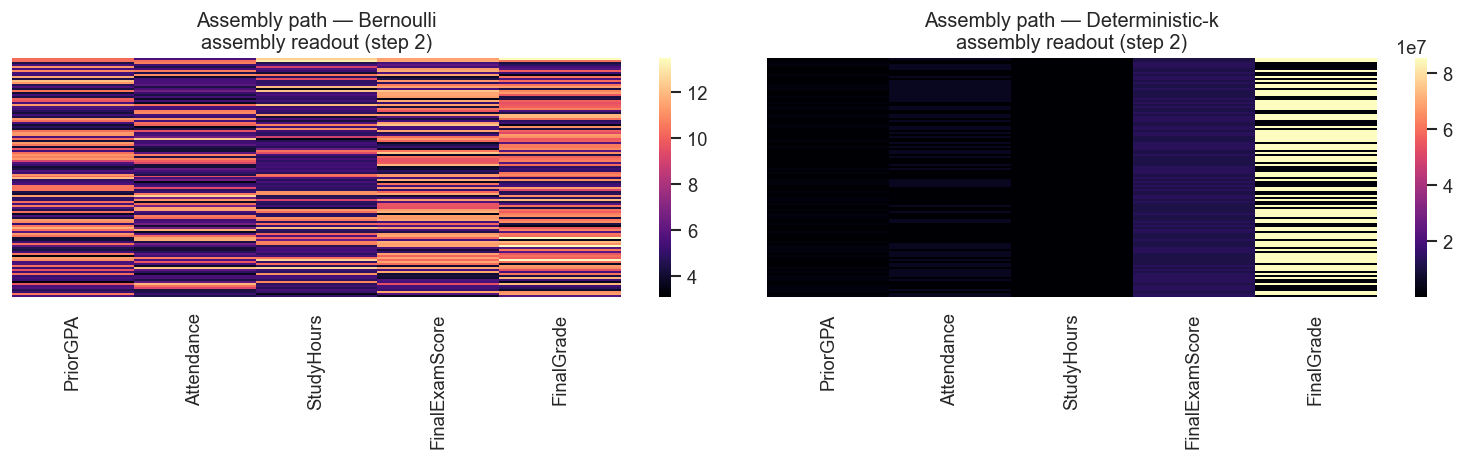

In [75]:
bern_assembly_df = assembly_readout(bern_neural, bern_brain)
detk_assembly_df = assembly_readout(detk_neural, detk_brain)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for ax, (label, df_feat) in zip(axes, [("Bernoulli", bern_assembly_df), ("Deterministic-k", detk_assembly_df)]):
    sns.heatmap(df_feat.head(120), ax=ax, cmap="magma", cbar=True,
                xticklabels=True, yticklabels=False)
    ax.set_title(f"Assembly path — {label}\nassembly readout (step 2)")
plt.tight_layout(); plt.show()

---
## Convergence — causal discovery and comparison

Both paths are now represented as DataFrames with one scalar per variable per sample.
The same `METHOD` (PC or GES) is applied to both under identical settings.

In [76]:
bern_neuron_edges   = discover(bern_neuron_df)
bern_assembly_edges = discover(bern_assembly_df)
detk_neuron_edges   = discover(detk_neuron_df)
detk_assembly_edges = discover(detk_assembly_df)

rows = []
for label, ne, ae in [("Bernoulli", bern_neuron_edges, bern_assembly_edges),
                       ("Deterministic-k", detk_neuron_edges, detk_assembly_edges)]:
    nm = compare_dags(GT_EDGES, ne, VAR_NAMES)
    am = compare_dags(GT_EDGES, ae, VAR_NAMES)
    rows.append({"encoding": label,
                 "neuron_edges": len(ne),   "neuron_f1":   round(nm["f1"], 3),
                 "assembly_edges": len(ae), "assembly_f1": round(am["f1"], 3)})
display(pd.DataFrame(rows))

,encoding,neuron_edges,neuron_f1,assembly_edges,assembly_f1
0,Bernoulli,4,1.000,5,0.444
1,Deterministic-k,5,0.889,4,0.750


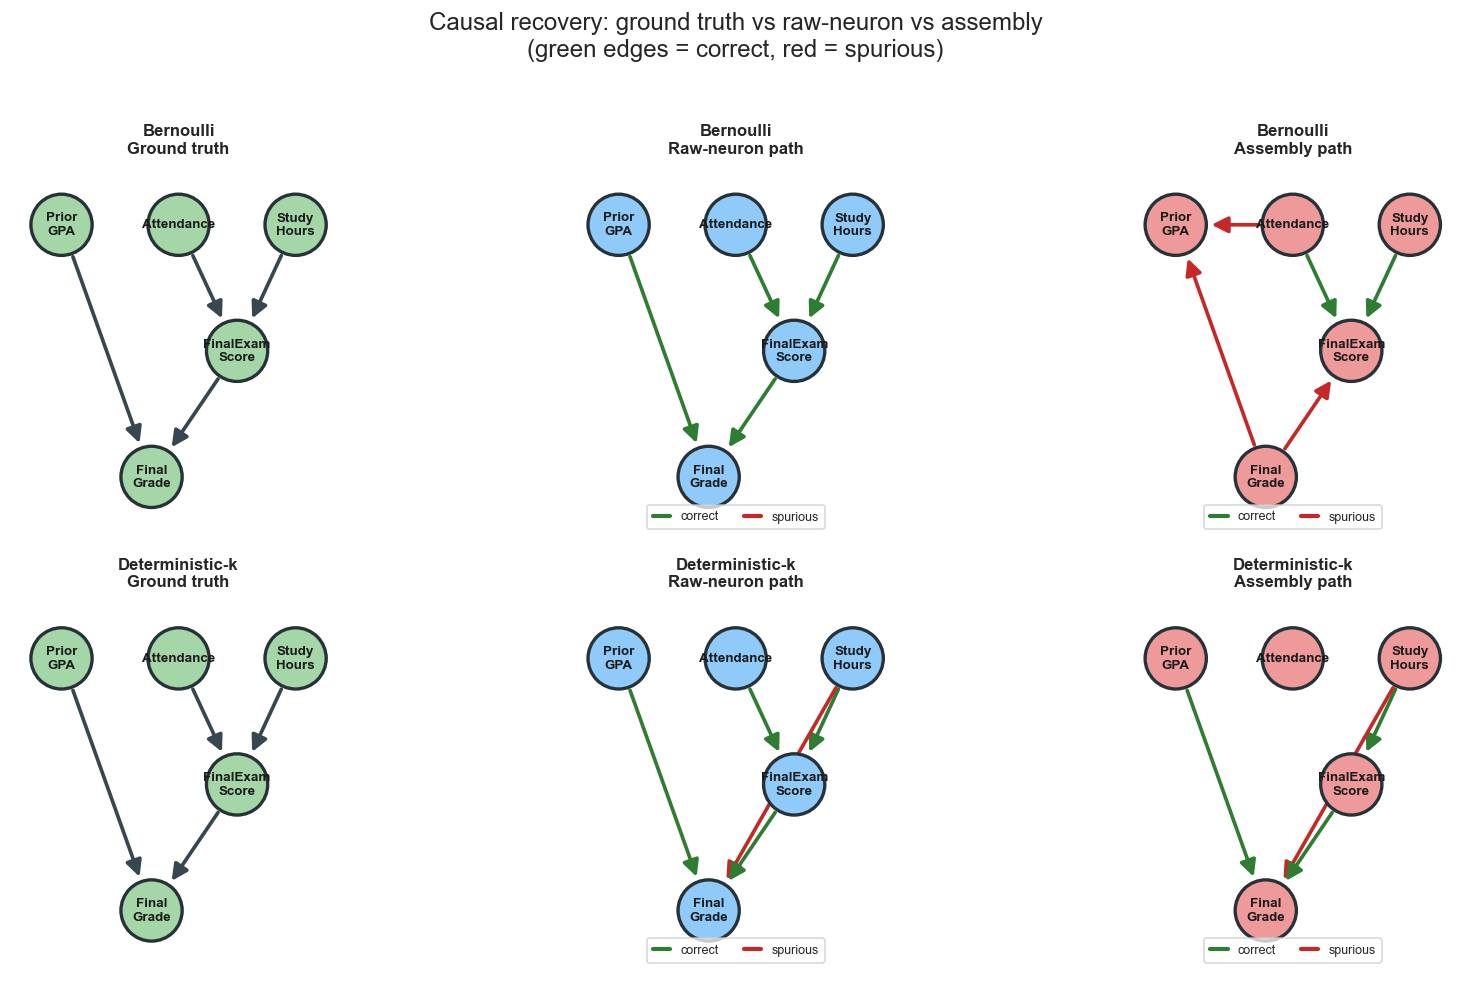

In [77]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
configs = [
    ("Bernoulli",      bern_neuron_edges, bern_assembly_edges),
    ("Deterministic-k", detk_neuron_edges, detk_assembly_edges),
]
for row, (label, n_edges, a_edges) in enumerate(configs):
    draw_dag(axes[row, 0], GT_EDGES,  f"{label}\nGround truth",     "#A5D6A7")
    draw_dag(axes[row, 1], n_edges,   f"{label}\nRaw-neuron path",   "#90CAF9", GT_EDGES)
    draw_dag(axes[row, 2], a_edges,   f"{label}\nAssembly path",     "#EF9A9A", GT_EDGES)
fig.suptitle("Causal recovery: ground truth vs raw-neuron vs assembly\n(green edges = correct, red = spurious)", y=1.02)
plt.tight_layout(); plt.show()

---
## Full runner output (with MI preservation log)

This cell runs the full `run_causal_dag_validation` pipeline for deterministic-k
and prints its stage-by-stage log.


In [78]:
from src.runner import run_causal_dag_validation
with contextlib.redirect_stdout(io.StringIO()) as buf:
    result = run_causal_dag_validation(
        df=df, var_names=VAR_NAMES, ground_truth_edges=GT_EDGES,
        neurons_per_var=NEURONS_PER_VAR, assembly_k=ASSEMBLY_K,
        n_train=N_TRAIN, n_presentations=N_PRESENTATIONS, beta=BETA,
        seed=SEED, method=METHOD, strict_causal_discovery=False,
        deterministic_k_encoding=True, deterministic_k_step=8,
        positive_values_map=POSITIVE_VALUES_MAP,
    )
print(buf.getvalue()[:6000])


CAUSAL STRUCTURE PRESERVATION PIPELINE
  Dataset: 1000 samples, 5 variables
  Ground Truth Edges: 4
  Paper flow: Stage I SCM observations (input) -> Stage II neural encoding
              -> Stage III raw-neuron baseline readout
              -> Stage IV assembly formation
              -> Stage V assembly readout -> Stage VI PC/GES graph recovery

[STAGE II] Neural Encoding...
  Encoded 1000 samples to 2,000 neurons (deterministic-k, base=40, step=8)

[STAGE III] Raw-neuron baseline readout...
  Raw-neuron readout features extracted: (1000, 5)

[STAGE IV] Assembly Formation (Papadimitriou Brain)...
  Training: 200 samples/var, 3 rounds -> 600 projections per area
  Assembly params: k=40 winners/projection; w=support size (union of winners)
    PriorGPA: k=40, winners_now=40, support_w=207/400
    Attendance: k=40, winners_now=40, support_w=167/400
    StudyHours: k=40, winners_now=40, support_w=171/400
    FinalExamScore: k=40, winners_now=40, support_w=123/400
    FinalGrade: k=40,